# $h_y$ sweep — first-order transition vs $L$
Pure-$Y$ field ($h_x=h_z=0$), $h_y\in[0.80,1.20]$, CNN ansatz. Keeps **converged** runs (finite energy that has plateaued over the last 20 steps) — this admits walltime-killed-but-converged partials (e.g. the L=8 topological-phase points) while rejecting NaN-diverged and too-early runs. The transition shows as a **discontinuity** in $\langle\sigma^y\rangle$ / $\langle B_p\rangle$.

In [1]:
import json, re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3})
NQS = Path("../results/nqs"); FIG = Path("../figures"); FIG.mkdir(exist_ok=True)

In [2]:
ARM = "cnn"

def energies(d):
    out = []
    for x in d["energy"]:
        try: out.append(complex(x).real)
        except (ValueError, TypeError): out.append(np.nan)
    return np.array(out)

def converged(d):                          # finite final E + energy plateaued over last 20 steps
    E = energies(d)                        # admits walltime-killed partials that already converged,
    if len(E) < 100 or not np.isfinite(E[-1]):   # while rejecting NaN-diverged and too-early runs
        return False
    return np.std(E[-20:]) / abs(np.mean(E[-20:])) < 5e-3

def sweep(L):                              # {hy: data} for converged runs (no .mpack requirement)
    out = {}
    for p in sorted(NQS.glob(f"G-equiv_1_L{L}_hx0.00_hy*_{ARM}.json")):
        d = json.load(open(p))
        if converged(d):
            out[float(re.search(r"hy([\d.]+)_", p.name).group(1))] = d
    return out

sy = lambda d: np.mean(d["order_params"]["magnetization_Ymean"][-1])  # <sigma^y> order param
bp = lambda d: d["order_params"]["Bp_mean"][-1]                       # <B_p> plaquette stabilizer
en = lambda d: energies(d)[-1]                                        # converged energy

Ls = [L for L in (4, 6, 8) if sweep(L)]
data = {L: sweep(L) for L in Ls}
cols = dict(zip(Ls, plt.cm.viridis(np.linspace(0, 0.75, len(Ls)))))

def curve(L, fn):
    hy = np.array(sorted(data[L]))
    return hy, np.array([fn(data[L][h]) for h in hy])

{L: sorted(data[L]) for L in Ls}          # what got loaded

{4: [0.8, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.15, 1.2],
 6: [0.8, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.15, 1.2],
 8: [0.8, 0.85, 0.9, 0.95, 1.0]}

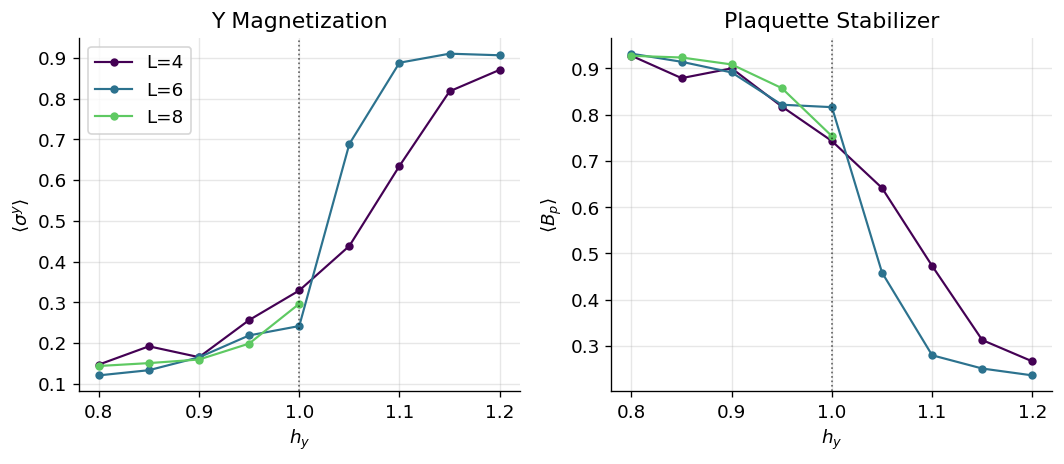

In [3]:
# order parameters vs h_y — the first-order jump
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 4), sharex=True)
for L in Ls:
    hy, y = curve(L, sy); a1.plot(hy, y, "o-", color=cols[L], ms=4, lw=1.3, label=f"L={L}")
    hy, y = curve(L, bp); a2.plot(hy, y, "o-", color=cols[L], ms=4, lw=1.3, label=f"L={L}")
for ax in (a1, a2):
    ax.axvline(1.0, color="k", ls=":", lw=1, alpha=0.6)               # theory h_c=1
    ax.set_xlabel("$h_y$")
a1.set(ylabel=r"$\langle\sigma^y\rangle$", title="Y Magnetization")
a2.set(ylabel=r"$\langle B_p\rangle$", title="Plaquette Stabilizer")
a1.legend()
fig.tight_layout()
fig.savefig(FIG / "hy_orderparams_vs_L.png", dpi=300, bbox_inches="tight")

L=4: steepest d<sy>/dhy near h_y=1.10
L=6: steepest d<sy>/dhy near h_y=1.05
L=8: steepest d<sy>/dhy near h_y=1.00


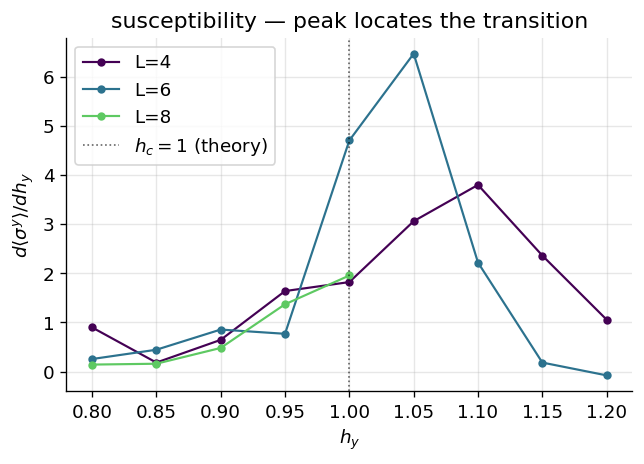

In [4]:
# derivative sharpens the discontinuity: peak in d<sigma^y>/dh_y locates h_c(L)
fig, ax = plt.subplots(figsize=(5.5, 4))
for L in Ls:
    hy, y = curve(L, sy)
    ax.plot(hy, np.gradient(y, hy), "o-", color=cols[L], ms=4, lw=1.3, label=f"L={L}")
    print(f"L={L}: steepest d<sy>/dhy near h_y={hy[np.argmax(np.gradient(y, hy))]:.2f}")
ax.axvline(1.0, color="k", ls=":", lw=1, alpha=0.6, label="$h_c=1$ (theory)")
ax.set(xlabel="$h_y$", ylabel=r"$d\langle\sigma^y\rangle/dh_y$",
       title="susceptibility — peak locates the transition")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "hy_dsy_vs_L.png", dpi=300, bbox_inches="tight")